## Why did you choose this project?

### I selected the BigMart Sales Prediction project because it solves a real business problem—forecasting product sales. It allowed me to practice the complete machine learning lifecycle, including data preprocessing, exploratory data analysis, feature engineering, regression modeling, evaluation, and generating business insights.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

In [2]:
# Loading Dataset
test_data = pd.read_csv(r'C:\Users\soura\Desktop\Projects\Machine Learing Project\Bigmart Sales Prediction\Data\test.csv')
train_data = pd.read_csv(r'C:\Users\soura\Desktop\Projects\Machine Learing Project\Bigmart Sales Prediction\Data\train.csv')

In [3]:
test_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [4]:
train_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
# Rows and Columns in the dataset
print(f'Train data- {train_data.shape}')
print(f'Test data- {test_data.shape}')

Train data- (8523, 12)
Test data- (5681, 11)


### Initial Data Inspection

In [6]:
train_data.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [7]:
train_data.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [9]:
train_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [10]:
train_data.describe(include='object')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [11]:
train_data.sample(5,random_state= 42)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7503,FDI28,14.300,Low Fat,0.026300,Frozen Foods,79.4302,OUT013,1987,High,Tier 3,Supermarket Type1,1743.0644
2957,NCM17,7.930,Low Fat,0.071136,Health and Hygiene,42.7086,OUT046,1997,Small,Tier 1,Supermarket Type1,356.8688
7031,FDC14,14.500,Regular,0.041313,Canned,42.0454,OUT049,1999,Medium,Tier 1,Supermarket Type1,377.5086
1084,DRC36,NaN,Regular,0.044767,Soft Drinks,173.7054,OUT027,1985,Medium,Tier 3,Supermarket Type3,5778.4782
856,FDS27,10.195,Regular,0.012456,Meat,197.5110,OUT035,2004,Small,Tier 2,Supermarket Type1,2356.9320


### Data Quality Assessment

In [12]:
# Check for the null values
train_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [13]:
# Check for the duplicates rows
train_data.duplicated().sum()

np.int64(0)

In [14]:
# Check unique values in each categorical columns

categorical_values = train_data.select_dtypes(include='object').columns

for col in categorical_values:
    print("-"*50)
    print(col)
    print(train_data[col].value_counts())

--------------------------------------------------
Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64
--------------------------------------------------
Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Nam

In [15]:
categorical_values

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

### Data Cleaning

In [16]:
# Find How many missing values are present in the dataset
train_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [17]:
# Missing values in percentage
(train_data.isnull().sum()/len(train_data))*100

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

In [18]:
train_data['Item_Weight'].describe()

count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64

<Axes: >

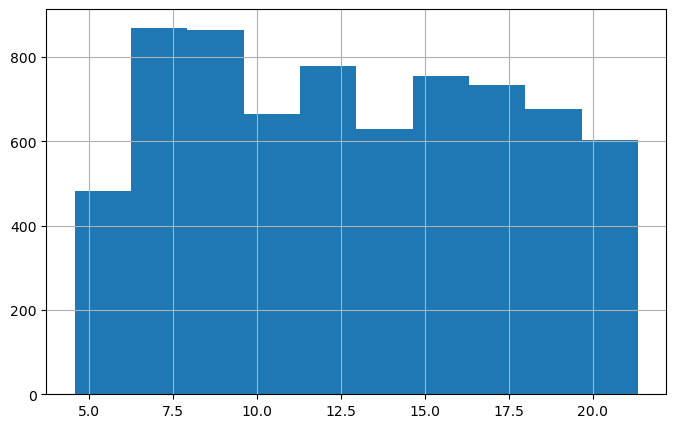

In [19]:
train_data["Item_Weight"].hist(figsize=(8,5))

In [20]:
train_data['Outlet_Size'].value_counts(dropna=False)

Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64

In [21]:
# Fill missing values
train_data['Outlet_Size'].fillna(train_data['Outlet_Size'].mode()[0],inplace=True)
test_data['Outlet_Size'].fillna(test_data['Outlet_Size'].mode()[0],inplace=True)

C:\Users\soura\AppData\Local\Temp\ipykernel_14092\175981665.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Outlet_Size'].fillna(train_data['Outlet_Size'].mode()[0],inplace=True)
C:\Users\soura\AppData\Local\Temp\ipykernel_14092\175981665.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [22]:
train_data['Item_Weight']= train_data['Item_Weight'].fillna(
    train_data['Item_Weight'].median())

test_data['Item_Weight']= test_data['Item_Weight'].fillna(
    test_data['Item_Weight'].median())

In [23]:
# Again check missing values after filling them with median
train_data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [24]:
train_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [25]:
# Replacing Values

train_data['Item_Fat_Content']= train_data['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

test_data['Item_Fat_Content']= test_data['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

In [26]:
train_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

### Step Item Visibility - 

In [27]:
(train_data['Item_Visibility']==0).sum()

np.int64(526)

In [28]:
(train_data['Item_Visibility']==0).sum() / len(train_data)*100

np.float64(6.1715358441863195)

In [29]:
train_data[train_data['Item_Visibility']==0].head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.200,Regular,0.0,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
10,FDY07,11.800,Low Fat,0.0,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266
32,FDP33,18.700,Low Fat,0.0,Snack Foods,256.6672,OUT018,2009,Medium,Tier 3,Supermarket Type2,3068.0064


### Check Duplicate

In [30]:
train_data.duplicated().sum()

np.int64(0)

### Outlier Detection

In [31]:
# Identify Numeric Columns

num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

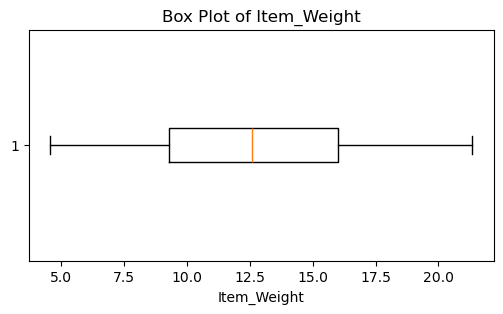

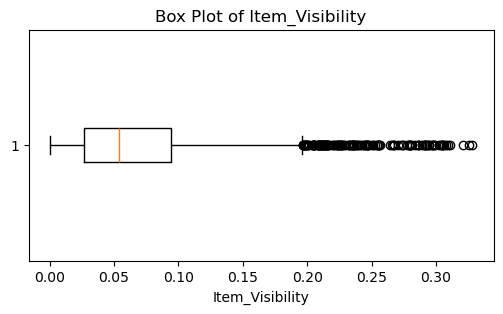

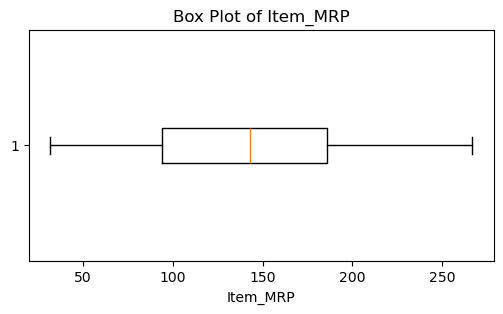

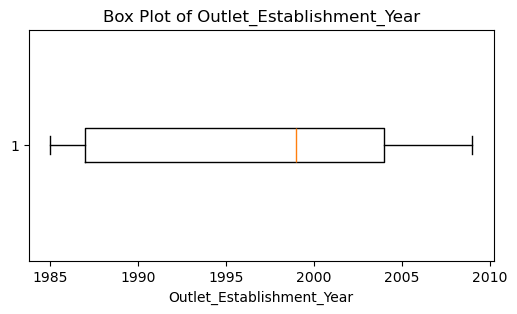

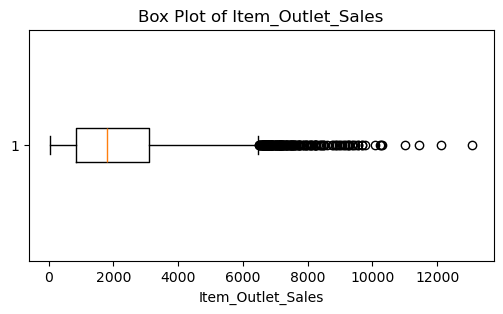

In [32]:
# Draw Box Plot
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(train_data[col], vert=False)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()
               

In [33]:
# Detect Outlier Using IQR

def detect_outlier_iqr(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    Outliers = df[(df[column]<lower)|(df[column]>upper)]

    print(f'{column}')
    print(f'Lower Bound: {lower:.2f}')
    print(f'Upper Bound: {upper:.2f}')
    print(f'Outliers: {len(Outliers)}')
    print('-'*40)

In [34]:
for col in num_cols:
    detect_outlier_iqr(train_data, col)

Item_Weight
Lower Bound: -0.72
Upper Bound: 26.04
Outliers: 0
----------------------------------------
Item_Visibility
Lower Bound: -0.07
Upper Bound: 0.20
Outliers: 144
----------------------------------------
Item_MRP
Lower Bound: -43.90
Upper Bound: 323.37
Outliers: 0
----------------------------------------
Outlet_Establishment_Year
Lower Bound: 1961.50
Upper Bound: 2029.50
Outliers: 0
----------------------------------------
Item_Outlet_Sales
Lower Bound: -2566.33
Upper Bound: 6501.87
Outliers: 186
----------------------------------------


## Outlier Detection

### Method Used
- IQR (Interquartile Range)

### Results

| Feature | Outliers | Action |
|----------|---------:|--------|
| Item_Weight | 0 | No Action |
| Item_Visibility | 144 | Retained |
| Item_MRP | 0 | No Action |
| Outlet_Establishment_Year | 0 | No Action |
| Item_Outlet_Sales | 186 | Retained |

### Conclusion

Potential outliers were found in Item_Visibility and Item_Outlet_Sales. These values were retained because they represent valid business scenarios rather than data errors.

## Exploratory Data Analysis (EDA)

## 11.1 Distribution of Item_Outlet_Sales

### Objective

To understand how product sales are distributed and identify whether the target variable is normally distributed or skewed.

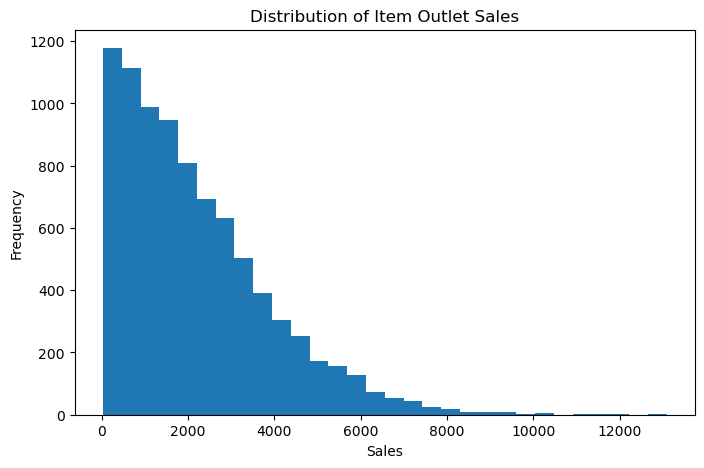

In [35]:
plt.figure(figsize=(8,5))

plt.hist(train_data['Item_Outlet_Sales'], bins=30)

plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

### Observation

- The target variable (Item_Outlet_Sales) is not normally distributed.
- The distribution is positively (right) skewed.
- Most products have sales between 0 and 3000.
- Only a small number of products have very high sales.
- A few extreme high-value sales are present.

### Business Insight

Most products generate low to moderate sales, while only a few products contribute exceptionally high sales.

This suggests that identifying the factors responsible for these high-selling products can help improve overall business revenue.

## 11.2 Distribution of Item_MRP

### Objective

To understand the price distribution of products and identify whether products are concentrated in a specific price range.

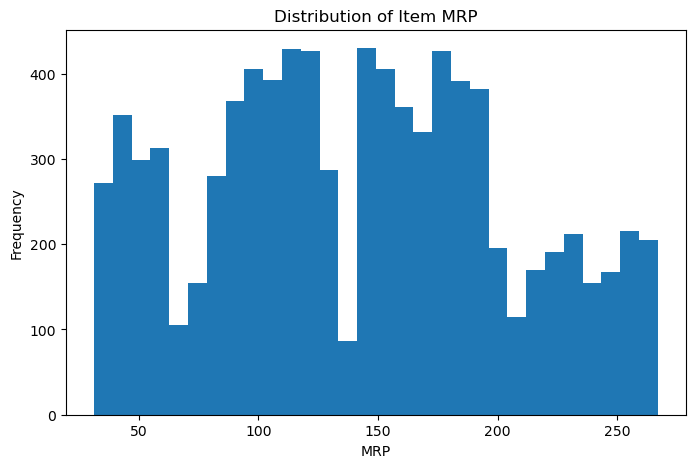

In [36]:
plt.figure(figsize=(8,5))

plt.hist(train_data['Item_MRP'], bins=30)

plt.title('Distribution of Item MRP')
plt.xlabel('MRP')
plt.ylabel('Frequency')

plt.show()

### Observation

- Item_MRP is not normally distributed.
- Multiple peaks are observed in the histogram.
- Products are grouped into different price ranges.
- The distribution suggests the presence of multiple pricing segments.

### Business Insight

Products are available across multiple pricing segments rather than a single continuous price range.

This indicates that the retailer follows a segmented pricing strategy to target different customer groups.

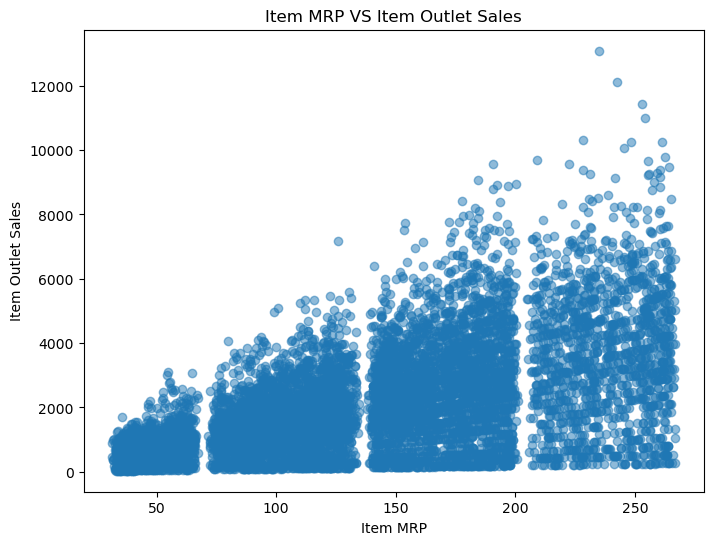

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    train_data['Item_MRP'],
    train_data['Item_Outlet_Sales'],
    alpha=0.5
)

plt.title('Item MRP VS Item Outlet Sales')
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')

plt.show()

### Observation

- Item MRP and Item Outlet Sales show a positive relationship.
- The relationship is moderate, not perfectly linear.
- Products are grouped into multiple MRP segments.
- Higher MRP products generally have the potential for higher sales.
- Sales variability increases as MRP increases.

### Business Insight

Increasing product price alone does not guarantee higher sales.

Other factors such as outlet characteristics, product category, and product visibility also influence sales performance.

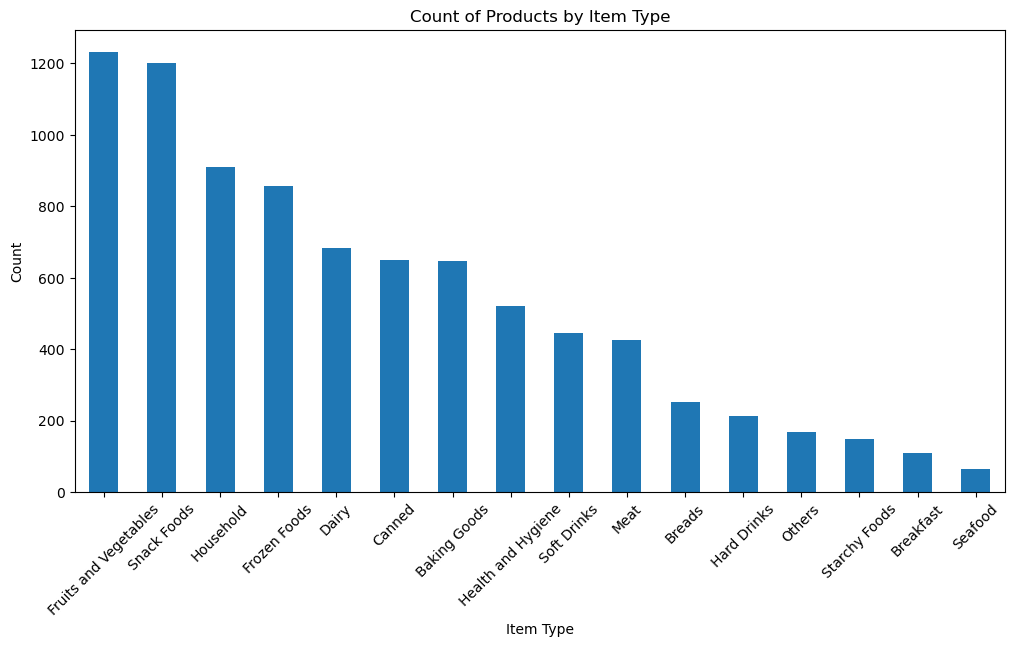

In [38]:
plt.figure(figsize=(12,6))

train_data['Item_Type'].value_counts().plot(kind='bar')

plt.title("Count of Products by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

### Observation

- Fruits & Vegetables has the highest number of products.
- Snack Foods is the second-largest category.
- Seafood has the lowest number of products.
- Product distribution across categories is imbalanced.

### Business Insight

The retailer allocates more products to high-demand categories such as Fruits & Vegetables and Snack Foods.

Low-count categories may represent niche products or categories with lower customer demand.

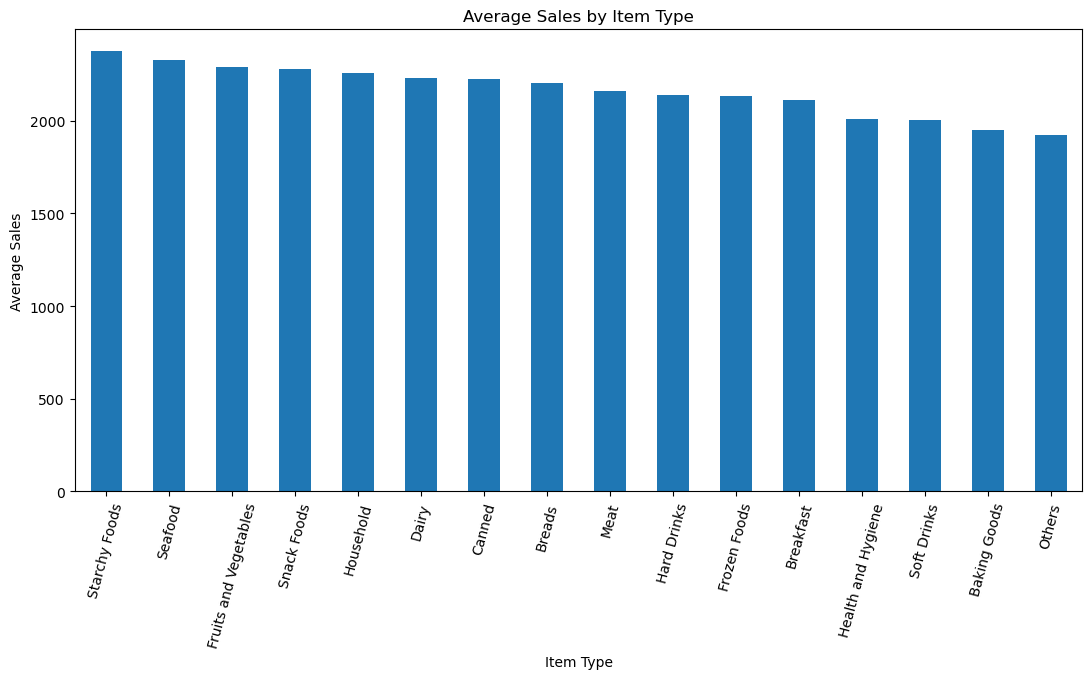

In [39]:
# Average Sales by Item Type

plt.figure(figsize=(13,6))

avg_sales = train_data.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)

avg_sales.plot(kind='bar')

plt.title('Average Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Average Sales')

plt.xticks(rotation=75)
    
plt.show()

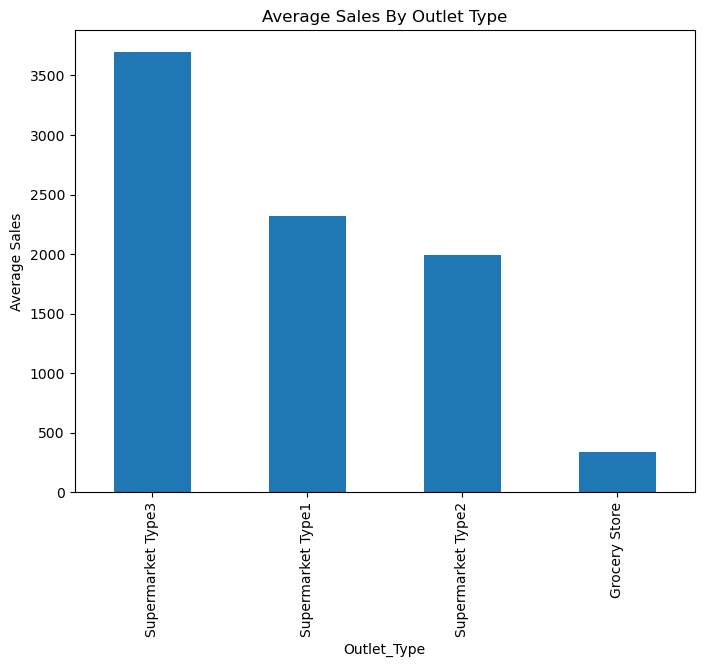

In [40]:
# Average Sales by Outlet Type

train_data.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(8,6))

plt.title('Average Sales By Outlet Type')
plt.ylabel('Average Sales')
plt.show()

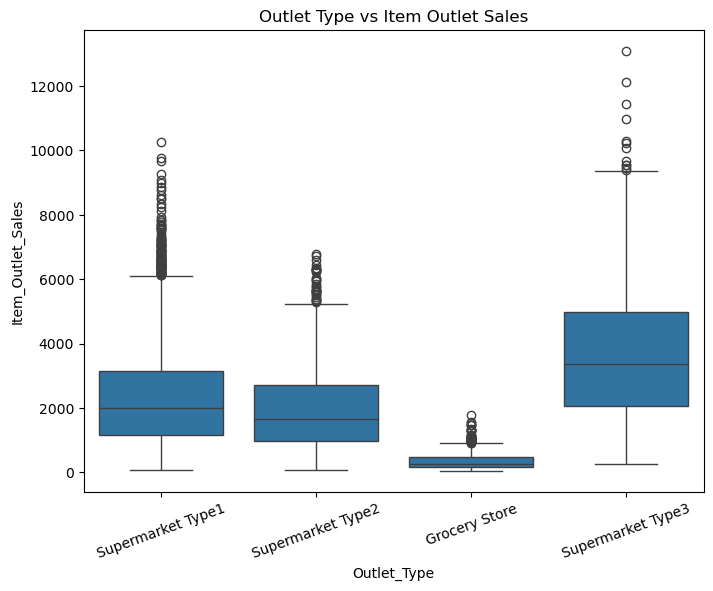

In [41]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(x= 'Outlet_Type', y='Item_Outlet_Sales', data= train_data)

plt.title('Outlet Type vs Item Outlet Sales')

plt.xticks(rotation=20)
plt.show()

### Feature Engineering

Feature Engineering is the process of creating, modifying, or transforming variables (features) so that a Machine Learning model can learn patterns more effectively.

A good feature engineering process often improves model performance more than changing the machine learning algorithm.

The goal is to convert raw data into meaningful information that helps the model make better predictions.

#### Why?
- Improve model accuracy
- Create more informative features
- Remove unnecessary information
- Convert categorical variables into numerical form
- Handle skewed distributions
- Extract hidden patterns from existing columns

##### Steps:-
In this project we will perform the following tasks:

1. Create Outlet Age from Outlet Establishment Year
2. Encode categorical variables
3. Transform skewed numerical features if required
4. Create new useful features (if necessary)
5. Prepare data for Machine Learning models


In [42]:
# Creating Outlet Age

Current_year = 2026

Outlet_Age = Current_year- train_data['Outlet_Establishment_Year']

In [43]:
Outlet_Age.sample(10)

4933    24
6725    41
1408    29
2926    27
4787    22
0       27
2073    41
3452    39
4665    19
2482    29
Name: Outlet_Establishment_Year, dtype: int64

In [44]:
# Saving into DataFrame 

current_year = 2026

train_data['Outlet_Age']= Current_year- train_data['Outlet_Establishment_Year']
test_data['Outlet_Age']= Current_year- test_data['Outlet_Establishment_Year']

In [45]:
train_data['Outlet_Age'].head()

0    27
1    17
2    27
3    28
4    39
Name: Outlet_Age, dtype: int64

A new feature called **Outlet_Age** was created from the existing
**Outlet_Establishment_Year** column.

Instead of giving the model the establishment year, we provide the age of the outlet, which is more meaningful and easier for the model to interpret.

Older outlets may have more customer trust, experience, and brand value, which can influence sales.

In [46]:
train_data['Outlet_Age'].describe()

count    8523.000000
mean       28.168133
std         8.371760
min        17.000000
25%        22.000000
50%        27.000000
75%        39.000000
max        41.000000
Name: Outlet_Age, dtype: float64

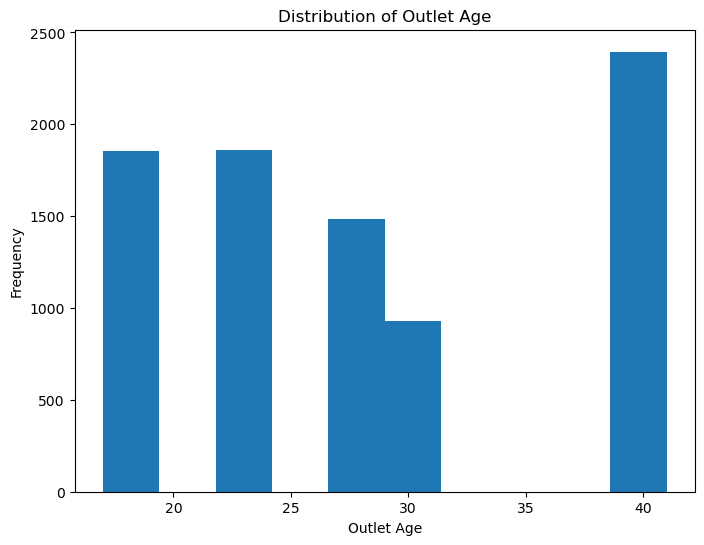

In [47]:
plt.figure(figsize=(8,6))
plt.hist(train_data['Outlet_Age'],bins=10)
plt.title('Distribution of Outlet Age')
plt.xlabel('Outlet Age')
plt.ylabel('Frequency')
plt.show()

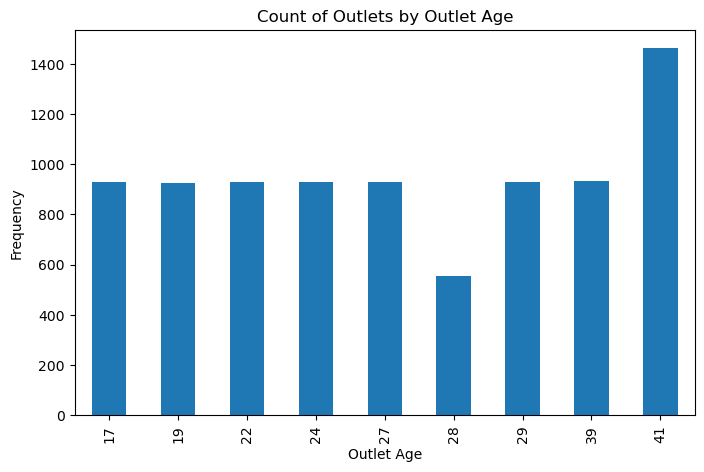

In [48]:
train_data['Outlet_Age'].value_counts().sort_index().plot(
    kind='bar',
    figsize= (8,5),
)

plt.title('Count of Outlets by Outlet Age')
plt.xlabel('Outlet Age')
plt.ylabel('Frequency')
plt.show()

### Observation

- The Outlet Age feature is not normally distributed.
- Most outlets belong to a few specific age groups.
- 41-year-old outlets are the most common.
- Newer outlets are comparatively fewer.
- This indicates that the company expanded its stores during a few specific time periods rather than continuously.
- Outlet Age may become an important feature because older stores often have stronger customer trust and market presence, which can influence sales.

#### Feature Engineering - Item Category

### Why are we creating Item Category?

The `Item_Identifier` column contains hidden information.

The first two characters of every Item Identifier represent the product category.

For example:

- FD → Food
- DR → Drinks
- NC → Non-Consumable

Instead of giving the complete identifier to the model, we extract the category because it provides meaningful information and helps the model learn better.

In [49]:
train_data['Item_Identifier']

0       FDA15
1       DRC01
2       FDN15
3       FDX07
4       NCD19
        ...  
8518    FDF22
8519    FDS36
8520    NCJ29
8521    FDN46
8522    DRG01
Name: Item_Identifier, Length: 8523, dtype: object

In [50]:
train_data['Item_Category'] = train_data['Item_Identifier'].str[:2]
test_data['Item_Category'] = test_data['Item_Identifier'].str[:2]

In [51]:
print(test_data['Item_Category'])
print(test_data['Item_Category'])

0       FD
1       FD
2       NC
3       FD
4       FD
        ..
5676    FD
5677    FD
5678    NC
5679    FD
5680    FD
Name: Item_Category, Length: 5681, dtype: object
0       FD
1       FD
2       NC
3       FD
4       FD
        ..
5676    FD
5677    FD
5678    NC
5679    FD
5680    FD
Name: Item_Category, Length: 5681, dtype: object


In [52]:
train_data['Item_Category']= train_data['Item_Category'].replace({
    'FD':'Food',
    'DR':'Drinks',
    'NC':'Non-Consumable'
    })
test_data['Item_Category']= test_data['Item_Category'].replace({
    'FD':'FOOD',
    'DR':'Drinks',
    'NC':'Non-Consumable'
})

In [53]:
train_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27,Food
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17,Drinks
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27,Food
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,28,Food
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39,Non-Consumable


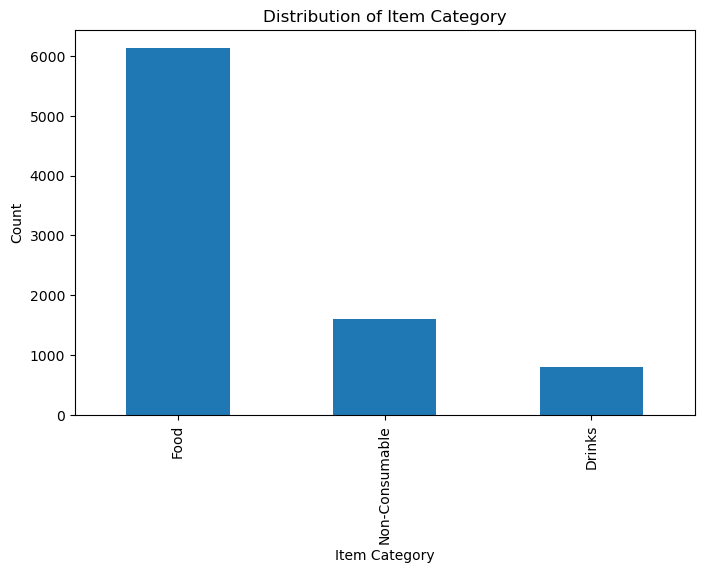

In [54]:
plt.figure(figsize=(8,5))

train_data['Item_Category'].value_counts().plot(kind='bar')

plt.title('Distribution of Item Category')
plt.xlabel('Item Category')
plt.ylabel('Count')
plt.show()

### Observations

- Food is the most common item category in the dataset.
- Drinks have the lowest number of products.
- The distribution is highly imbalanced, with Food dominating the dataset.
- More than 70% of the products belong to the Food category.
- The business appears to rely heavily on Food products.


#### Feature: Outlet_Identifier

###### Observation

Sabhi values "OUT" se start hoti hain.
"OUT" part har row me same hai, isliye koi information provide nahi karta.
Numeric part sirf outlet ka unique ID hai.
Ye IDs kisi logical order ya business meaning ko represent nahi karte.

##### Decision

Model ke liye ye feature useful nahi hai.
One-Hot Encoding karne par unnecessary dummy variables banenge.
Isse model unnecessarily complex ho sakta hai aur overfitting ka risk badh sakta hai.

Action

✅ Drop Outlet_Identifier

In [55]:
# Encoding (Categorical Features ko Numerical banana)

In [56]:
train_data.select_dtypes(include='object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
      dtype='object')

In [57]:
# # Drop Columns
# train_data.drop('Outlet_Identifier',axis=1,inplace=True)
# test_data.drop('Outlet_Identifier',axis=1,inplace=True)

In [58]:
# # Drop Columns
# train_data.drop('Item_Identifier',axis=1,inplace=True)
# test_data.drop('Item_Identifier',axis=1,inplace=True)

### Observation

- All values start with the prefix **"OUT"**.
- The **"OUT"** prefix is the same for every record and does not provide any useful information.
- The numeric part represents only a unique outlet identifier.
- These IDs do not have any meaningful order or business significance.

In [59]:
test_data

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_Category
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,27,FOOD
1,FDW14,8.300,Regular,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,19,FOOD
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,28,Non-Consumable
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,19,FOOD
4,FDY38,12.500,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,41,FOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1,29,FOOD
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2,17,FOOD
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,Medium,Tier 2,Supermarket Type1,24,Non-Consumable
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,Medium,Tier 2,Supermarket Type1,19,FOOD


## Feature Engineering - Handling Zero Visibility

### Objective

The `Item_Visibility` feature represents the visibility of a product inside a retail store.

A value of exactly **0** is not realistic because every product occupies some shelf space and has at least some visibility.

Therefore, zero values are treated as missing or invalid observations and replaced with more meaningful values.

### Why is this important?

- Prevents misleading information from reaching the model.
- Improves data quality.
- Helps the model learn more realistic patterns.

In [60]:
(train_data['Item_Visibility']==0).sum()


np.int64(526)

In [61]:
(test_data['Item_Visibility']==0).sum()

np.int64(353)


### Problem

Some products have a visibility value of **0**, which is unrealistic because every product occupies some shelf space.

### Solution

Instead of replacing zero values with the overall mean, we replaced them with the average visibility of the same product (`Item_Identifier`).

### Why?

- Different products naturally have different visibility levels.
- Product-specific averages preserve the original data distribution.
- This approach is more realistic and helps the model learn better patterns.

In [62]:
# Replace Item_Visibiltiy == 0 with the average of the same product

visibility_avg= train_data.groupby('Item_Identifier')['Item_Visibility'].transform('mean')

train_data['Item_Visibility'] = train_data['Item_Visibility'].mask(
     train_data['Item_Visibility']== 0, 
     visibility_avg
 )                                                                   

In [63]:
# Replace Item_Visibiltiy == 0 with the average of the same product

visibility_avg= test_data.groupby('Item_Identifier')['Item_Visibility'].transform('mean')

test_data['Item_Visibility'] = train_data['Item_Visibility'].mask(
     train_data['Item_Visibility']== 0, 
     visibility_avg
 )                                                                   

## Data Leakage

### What is Data Leakage?

Data Leakage occurs when information from the test dataset is unintentionally used during the training process.

This gives the model access to future or unseen information, resulting in overly optimistic performance that cannot be achieved in real-world scenarios.

### Best Practice

- Learn all statistics (mean, median, mappings, encoders, etc.) from the training dataset.
- Apply the learned values to the test dataset.
- Never combine training and test datasets before feature engineering or preprocessing.

### Why is this important?

Preventing data leakage ensures that the model is evaluated fairly and performs reliably on unseen data.

In [64]:
# Verify test data

(test_data['Item_Visibility']==0).sum()

np.int64(0)

In [65]:
# Verify test data

(train_data['Item_Visibility']==0).sum()

np.int64(0)

### Objective

The `Item_Visibility` feature contained zero values, which are unrealistic because every product in a retail store has some level of visibility.

### Approach

- Calculated the average visibility for each product using `Item_Identifier`.
- Replaced zero values with the average visibility of the corresponding product.
- Applied the same approach to both the training and test datasets.

### Why?

Different products naturally have different visibility levels. Using the product-specific average preserves this pattern and provides more realistic values than using a single overall average.

In [66]:
train_data

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27,Food
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17,Drinks
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27,Food
3,FDX07,19.200,Regular,0.015274,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,28,Food
4,NCD19,8.930,Low Fat,0.008082,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39,Non-Consumable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,39,Food
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850,24,Food
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,22,Non-Consumable
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,17,Food


## Feature Engineering - Non-Consumable Products

### Objective

The `Item_Fat_Content` feature is meaningful only for edible products.

However, some products belong to the `Non-Consumable` category, where fat content is not applicable.

### Approach

For all products where `Item_Category` is `Non-Consumable`, the `Item_Fat_Content` value was changed to **"Non-Edible"**.

### Why?

This improves the business meaning of the dataset and prevents the model from learning incorrect relationships between fat content and non-consumable products.

In [67]:
train_data.loc[
    train_data['Item_Category'] == 'Non-Consumable',
    'Item_Fat_Content'
] = 'Non-Edible'

test_data.loc[
    test_data['Item_Category'] == 'Non-Consumable',
    'Item_Fat_Content'
] = 'Non-Edible'

In [68]:
train_data.loc[
    train_data['Item_Category'] == 'Non-Consumable',
    'Item_Fat_Content'
].value_counts()

Item_Fat_Content
Non-Edible    1599
Name: count, dtype: int64

In [69]:
train_data[['Item_Category', 'Item_Fat_Content']].head(10)

,Item_Category,Item_Fat_Content
0,Food,Low Fat
1,Drinks,Regular
2,Food,Low Fat
3,Food,Regular
4,Non-Consumable,Non-Edible
5,Food,Regular
6,Food,Regular
7,Food,Low Fat
8,Food,Regular
9,Food,Regular


### Observation

Item_Fat_Content originally contained values such as Low Fat and Regular even for Non-Consumable products. Since non-consumable items cannot have fat content, these values were logically incorrect.

#### Action Taken

Created a new category "Non-Edible" for all products where:

Item_Category = Non-Consumable
##### Result

All 1599 Non-Consumable products were successfully assigned the value "Non-Edible", making the feature more meaningful and business-friendly.

In [70]:
# Clean Outlet_Size

train_data['Outlet_Size'].value_counts(dropna=False)

Outlet_Size
Medium    5203
Small     2388
High       932
Name: count, dtype: int64

In [71]:
test_data['Outlet_Size'].value_counts(dropna=False)

Outlet_Size
Medium    3468
Small     1592
High       621
Name: count, dtype: int64

In [72]:
train_data.select_dtypes(include='object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
      dtype='object')

## Removing Identifier Columns

### Objective

The `Item_Identifier` and `Outlet_Identifier` columns were used during feature engineering but do not provide meaningful predictive information for the model.

### Why were they removed?

- They are unique identifiers rather than business features.
- The useful information from `Item_Identifier` was already extracted into the `Item_Category` feature.
- Keeping these identifiers would increase model complexity without improving prediction performance.

### Action

Dropped:
- `Item_Identifier`
- `Outlet_Identifier`

In [73]:
# Drop Columns

train_data.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)
test_data.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)

In [74]:
train_data.sample(50)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category
4451,12.600,Regular,0.019673,Canned,86.4198,1985,Medium,Tier 3,Supermarket Type3,1918.8356,41,Food
7848,20.200,Non-Edible,0.112549,Household,123.1046,2002,Medium,Tier 2,Supermarket Type1,1120.5414,24,Non-Consumable
1587,9.695,Regular,0.029159,Canned,174.5370,2004,Small,Tier 2,Supermarket Type1,1235.0590,22,Food
5288,11.350,Regular,0.005526,Fruits and Vegetables,168.2790,1987,High,Tier 3,Supermarket Type1,2376.9060,39,Food
3344,8.850,Low Fat,0.053976,Fruits and Vegetables,181.5292,2002,Medium,Tier 2,Supermarket Type1,1277.0044,24,Food
6721,5.465,Regular,0.048802,Baking Goods,132.1626,2007,Medium,Tier 2,Supermarket Type1,1573.9512,19,Food
1256,12.600,Non-Edible,0.028723,Health and Hygiene,131.8310,1985,Medium,Tier 3,Supermarket Type3,3635.2680,41,Non-Consumable
6224,13.150,Low Fat,0.020758,Breads,84.3566,2002,Medium,Tier 2,Supermarket Type1,761.0094,24,Food
1402,20.000,Non-Edible,0.081454,Others,36.8190,1999,Medium,Tier 1,Supermarket Type1,768.9990,27,Non-Consumable
5272,21.100,Non-Edible,0.029173,Household,145.7786,2007,Medium,Tier 2,Supermarket Type1,1444.7860,19,Non-Consumable


In [75]:
train_data.shape

(8523, 12)

In [76]:
train_data['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

In [77]:
print(train_data['Outlet_Location_Type'].unique())

['Tier 1' 'Tier 3' 'Tier 2']


In [78]:
# Ordinal Encoding

Location_mapping = {
    'Tier 1':1,
    'Tier 2':2,
    'Tier 3':3
}

train_data['Outlet_Location_Type'] = train_data['Outlet_Location_Type'].map(Location_mapping)
test_data['Outlet_Location_Type']= test_data['Outlet_Location_Type'].map(Location_mapping)

In [79]:
size_mapping = {
    'Small':0,
    'Medium':1,
    'High':2}

train_data['Outlet_Size'] = train_data['Outlet_Size'].map(size_mapping)
test_data['Outlet_Size']= test_data['Outlet_Size'].map(size_mapping)

In [80]:
train_data[['Outlet_Size','Outlet_Location_Type']].head(20)

,Outlet_Size,Outlet_Location_Type
0,1,1
1,1,3
2,1,1
3,1,3
4,2,3
5,1,3
6,2,3
7,1,3
8,1,2
9,1,2


In [81]:
train_data['Outlet_Size'].value_counts()

Outlet_Size
1    5203
0    2388
2     932
Name: count, dtype: int64

In [82]:
train_data


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category
0,9.300,Low Fat,0.016047,Dairy,249.8092,1999,1,1,Supermarket Type1,3735.1380,27,Food
1,5.920,Regular,0.019278,Soft Drinks,48.2692,2009,1,3,Supermarket Type2,443.4228,17,Drinks
2,17.500,Low Fat,0.016760,Meat,141.6180,1999,1,1,Supermarket Type1,2097.2700,27,Food
3,19.200,Regular,0.015274,Fruits and Vegetables,182.0950,1998,1,3,Grocery Store,732.3800,28,Food
4,8.930,Non-Edible,0.008082,Household,53.8614,1987,2,3,Supermarket Type1,994.7052,39,Non-Consumable
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,1987,2,3,Supermarket Type1,2778.3834,39,Food
8519,8.380,Regular,0.046982,Baking Goods,108.1570,2002,1,2,Supermarket Type1,549.2850,24,Food
8520,10.600,Non-Edible,0.035186,Health and Hygiene,85.1224,2004,0,2,Supermarket Type1,1193.1136,22,Non-Consumable
8521,7.210,Regular,0.145221,Snack Foods,103.1332,2009,1,3,Supermarket Type2,1845.5976,17,Food


In [83]:
train_data['Outlet_Location_Type'].unique()

array([1, 3, 2])

#### One-Hot Encoding - Outlet_Type

##### Why?
Outlet_Type is a nominal categorical feature. There is no meaningful order among its categories (Grocery Store, Supermarket Type1, Type2, Type3). Assigning numerical values such as 1, 2, 3, and 4 would incorrectly imply an order.

##### Why One-Hot Encoding?

Creates separate binary columns for each category.
Prevents the model from assuming any ordinal relationship.
drop_first=True is used to avoid the Dummy Variable Trap (multicollinearity).

##### Action Taken 
Applied One-Hot Encoding on Outlet_Type.

In [84]:
train_data= pd.get_dummies(
    train_data,
    columns=['Outlet_Type'],
    drop_first=True,
    dtype= int)


In [85]:
test_data= pd.get_dummies(
    test_data,
    columns=['Outlet_Type'],
    drop_first=True,
    dtype=int)

In [86]:
train_data.columns.tolist()

['Item_Weight',
 'Item_Fat_Content',
 'Item_Visibility',
 'Item_Type',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Item_Outlet_Sales',
 'Outlet_Age',
 'Item_Category',
 'Outlet_Type_Supermarket Type1',
 'Outlet_Type_Supermarket Type2',
 'Outlet_Type_Supermarket Type3']

In [87]:
train_data

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Outlet_Age,Item_Category,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,Low Fat,0.016047,Dairy,249.8092,1999,1,1,3735.1380,27,Food,1,0,0
1,5.920,Regular,0.019278,Soft Drinks,48.2692,2009,1,3,443.4228,17,Drinks,0,1,0
2,17.500,Low Fat,0.016760,Meat,141.6180,1999,1,1,2097.2700,27,Food,1,0,0
3,19.200,Regular,0.015274,Fruits and Vegetables,182.0950,1998,1,3,732.3800,28,Food,0,0,0
4,8.930,Non-Edible,0.008082,Household,53.8614,1987,2,3,994.7052,39,Non-Consumable,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,1987,2,3,2778.3834,39,Food,1,0,0
8519,8.380,Regular,0.046982,Baking Goods,108.1570,2002,1,2,549.2850,24,Food,1,0,0
8520,10.600,Non-Edible,0.035186,Health and Hygiene,85.1224,2004,0,2,1193.1136,22,Non-Consumable,1,0,0
8521,7.210,Regular,0.145221,Snack Foods,103.1332,2009,1,3,1845.5976,17,Food,0,1,0


In [88]:
test_data

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Age,Item_Category,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,20.750,Low Fat,0.016047,Snack Foods,107.8622,1999,1,1,27,FOOD,1,0,0
1,8.300,Regular,0.019278,Dairy,87.3198,2007,1,2,19,FOOD,1,0,0
2,14.600,Non-Edible,0.016760,Others,241.7538,1998,1,3,28,Non-Consumable,0,0,0
3,7.315,Low Fat,0.015274,Snack Foods,155.0340,2007,1,2,19,FOOD,1,0,0
4,12.500,Regular,0.008082,Dairy,234.2300,1985,1,3,41,FOOD,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,10.500,Regular,0.095546,Snack Foods,141.3154,1997,0,1,29,FOOD,1,0,0
5677,7.600,Regular,0.018395,Starchy Foods,169.1448,2009,1,3,17,FOOD,0,1,0
5678,10.000,Non-Edible,0.087272,Health and Hygiene,118.7440,2002,1,2,24,Non-Consumable,1,0,0
5679,15.300,Regular,0.145465,Canned,214.6218,2007,1,2,19,FOOD,1,0,0


In [89]:
#feature
X = train_data.drop('Item_Outlet_Sales', axis=1)
#target
y = train_data['Item_Outlet_Sales']

In [90]:
X.shape

(8523, 13)

In [91]:
y.shape

(8523,)

# Feature Selection

Before training a machine learning model, the dataset is divided into:

- **Features (X):** Independent variables used to predict the target.
- **Target (y):** Dependent variable that the model will learn to predict.

In this project:

- **X** contains all input features.
- **y** contains the `Item_Outlet_Sales` column.

This separation is essential because machine learning algorithms require features and target variables independently.

In [92]:
X.dtypes

Item_Weight                      float64
Item_Fat_Content                  object
Item_Visibility                  float64
Item_Type                         object
Item_MRP                         float64
Outlet_Establishment_Year          int64
Outlet_Size                        int64
Outlet_Location_Type               int64
Outlet_Age                         int64
Item_Category                     object
Outlet_Type_Supermarket Type1      int64
Outlet_Type_Supermarket Type2      int64
Outlet_Type_Supermarket Type3      int64
dtype: object

In [93]:
X.select_dtypes(include='object').columns

Index(['Item_Fat_Content', 'Item_Type', 'Item_Category'], dtype='object')

In [94]:
train_data[['Item_Fat_Content', 'Item_Type', 'Item_Category']].head()

,Item_Fat_Content,Item_Type,Item_Category
0,Low Fat,Dairy,Food
1,Regular,Soft Drinks,Drinks
2,Low Fat,Meat,Food
3,Regular,Fruits and Vegetables,Food
4,Non-Edible,Household,Non-Consumable


In [95]:
train_data['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'Non-Edible'], dtype=object)

In [96]:
train_data['Item_Type'].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [97]:
train_data['Item_Category'].unique()

array(['Food', 'Drinks', 'Non-Consumable'], dtype=object)

In [98]:
from sklearn.preprocessing import LabelEncoder

In [99]:
from sklearn.preprocessing import LabelEncoder

le_fat = LabelEncoder()

train_data['Item_Fat_Content'] = le_fat.fit_transform(train_data['Item_Fat_Content'])


test_data['Item_Fat_Content'] = le_fat.transform(test_data['Item_Fat_Content'])

In [100]:
le_type = LabelEncoder()

train_data['Item_Type'] = le_type.fit_transform(train_data['Item_Type'])

test_data['Item_Type'] = le_type.transform(test_data['Item_Type'])

In [101]:
train_data['Item_Category'].unique()

array(['Food', 'Drinks', 'Non-Consumable'], dtype=object)

In [102]:
test_data['Item_Category'].unique()

array(['FOOD', 'Non-Consumable', 'Drinks'], dtype=object)

In [103]:
test_data['Item_Category'] = test_data['Item_Category'].replace({
    'FOOD':'Food'
})

In [104]:
test_data['Item_Category'].unique()

array(['Food', 'Non-Consumable', 'Drinks'], dtype=object)

In [105]:
le_cat = LabelEncoder()

train_data['Item_Category'] = le_cat.fit_transform(train_data['Item_Category'])

test_data['Item_Category'] = le_cat.transform(test_data['Item_Category'])

In [106]:
train_data.select_dtypes(include='object').columns

Index([], dtype='object')

In [107]:
test_data.select_dtypes(include='object').columns

Index([], dtype='object')

In [108]:
train_data[['Item_Fat_Content', 'Item_Type', 'Item_Category']].head()

,Item_Fat_Content,Item_Type,Item_Category
0,0,4,1
1,2,14,0
2,0,10,1
3,2,6,1
4,1,9,2


In [109]:
test_data[['Item_Fat_Content', 'Item_Type', 'Item_Category']].head()

,Item_Fat_Content,Item_Type,Item_Category
0,0,13,1
1,2,4,1
2,1,11,2
3,0,13,1
4,2,4,1


In [110]:
#feature
X = train_data.drop('Item_Outlet_Sales', axis=1)
#target
y = train_data['Item_Outlet_Sales']

In [111]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

# Encoding Remaining Categorical Features

Three categorical features were still stored as object data types:

- Item_Fat_Content
- Item_Type
- Item_Category

Since these features do not have a meaningful ordinal relationship, Label Encoding was applied to convert them into numeric values.

This step ensures that all input features are numerical and compatible with machine learning algorithms.

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42)
                                            

In [114]:
print(X_train.shape)
print(X_test.shape)
print('-'*50)
print(y_train.shape)
print(y_test.shape)

(6818, 13)
(1705, 13)
--------------------------------------------------
(6818,)
(1705,)


# Train-Test Split

Before training the machine learning model, the dataset was divided into training and testing sets.

- Training Set (80%) is used to train the model.
- Testing Set (20%) is used to evaluate how well the model performs on unseen data.

Using a separate test set helps measure the model's ability to generalize and reduces the risk of overfitting.

Random State = 42 was used to ensure reproducible results.

In [115]:
from sklearn.linear_model import LinearRegression

# Baseline Model - Linear Regression

Linear Regression ko baseline model ke roop me train kiya gaya.

Evaluation Metrics:

- R² Score
- MAE
- RMSE

Ye metrics batate hain ki model sales ko kitni accurately predict kar raha hai.

In [116]:
# Baseline Model (Model Selection)

lr= LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
# Prediction
train_pred = lr.predict(X_train)

test_pred = lr.predict(X_test)

In [118]:
# Evalution

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

print('Train R2:', r2_score(y_train, train_pred))
print('Train R2:', r2_score(y_test, test_pred))

print('Train Mean Absolute Error:', mean_absolute_error(y_train, train_pred))
print('Test Mean Absolute Error:', mean_absolute_error(y_test, test_pred))

print('Train Mean Squared Error:', mean_squared_error(y_train, train_pred))
print('Train Mean Squared Error:', mean_squared_error(y_test, test_pred))


Train R2: 0.5578163847323403
Train R2: 0.5798877873513906
Train Mean Absolute Error: 848.3367865233913
Test Mean Absolute Error: 791.6871924794207
Train Mean Squared Error: 1308001.3474520182
Train Mean Squared Error: 1141852.4185990398


In [119]:
import numpy as np

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))

Train RMSE: 1143.678865526516
Test RMSE: 1068.5749475816096


# Linear Regression - Model Evaluation

## Performance Summary

| Metric | Train | Test |
|--------|------:|-----:|
| R² Score | 0.558 | 0.580 |
| MAE | 848.34 | 791.69 |
| RMSE | 1143.68 | 1068.57 |

## Interpretation

- The Linear Regression model explains approximately **58%** of the variation in outlet sales.
- The difference between training and testing performance is very small, indicating that the model is **not overfitting**.
- The model serves as a good baseline for comparing more advanced algorithms such as Decision Tree and Random Forest.

## Conclusion

Linear Regression provides a reasonable baseline, but more powerful non-linear models may capture complex relationships and improve prediction accuracy.

In [120]:
#Random Forest Regressor

In [121]:
from sklearn.ensemble import RandomForestRegressor

In [122]:
# Create Model

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1)

In [123]:
# train Model
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
# Prediction 

train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)

In [125]:
# Evalution 

print('Train R2:', r2_score(y_train, train_pred_rf))
print('Test R2:', r2_score(y_test, test_pred_rf))

print('Train Mean Absolute Error:', mean_absolute_error(y_train, train_pred_rf))
print('Test Mean Absolute Error:', mean_absolute_error(y_test, test_pred_rf))

print('Train Mean Squared Error:', mean_squared_error(y_train, train_pred_rf))
print('Test Mean Squared Error:', mean_squared_error(y_test, test_pred_rf))


print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_rf)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_rf)))

Train R2: 0.9366738192112801
Test R2: 0.5633648237802511
Train Mean Absolute Error: 299.9065075555881
Test Mean Absolute Error: 760.3011020445748
Train Mean Squared Error: 187322.02402049
Test Mean Squared Error: 1186761.3389971952
Train RMSE: 432.80714414215714
Test RMSE: 1089.3857622519192


# Random Forest - Model Evaluation

## Performance Summary

| Metric | Train | Test |
|--------|------:|-----:|
| R² Score | 0.937 | 0.563 |
| MAE | 299.91 | 760.30 |
| RMSE | 432.81 | 1089.39 |

## Interpretation

- The Random Forest model achieved excellent performance on the training data.
- However, the testing performance dropped significantly.
- This indicates that the model has overfitted the training dataset.

## Conclusion

Random Forest showed signs of overfitting. Before applying hyperparameter tuning, additional baseline models (Ridge and Lasso Regression) will be evaluated. The best-performing model will then be selected for hyperparameter tuning and final optimization.

# Ridge Regression (L2 Regularization)

## Objective

Ridge Regression is an extension of Linear Regression that adds an L2 penalty to the loss function. It helps reduce overfitting by shrinking the coefficients while retaining all features.

## Why Ridge Regression?

- Reduces overfitting.
- Handles multicollinearity.
- Improves model generalization.
- Keeps all features in the model.

## Model Parameter

- Alpha = 1.0

The model will be compared with Linear Regression to evaluate whether regularization improves performance.

In [126]:
# Regularization

from sklearn.linear_model import Ridge

In [127]:
# Create Model
ridge = Ridge(alpha=1.0)

In [128]:
# Train Model
ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [129]:
# Prediction 

train_pred_ridge = ridge.predict(X_train)
test_pred_ridge = ridge.predict(X_test)

In [130]:
# Evalution 

print('Train R2:', r2_score(y_train, train_pred_ridge))
print('Test R2:', r2_score(y_test, test_pred_ridge))

print('Train Mean Absolute Error:', mean_absolute_error(y_train, train_pred_ridge))
print('Test Mean Absolute Error:', mean_absolute_error(y_test, test_pred_ridge))

print('Train Mean Squared Error:', mean_squared_error(y_train, train_pred_ridge))
print('Test Mean Squared Error:', mean_squared_error(y_test, test_pred_ridge))


print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_ridge)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_ridge)))

Train R2: 0.5578122097449392
Test R2: 0.5799076412501478
Train Mean Absolute Error: 848.2157214241374
Test Mean Absolute Error: 791.5947394300772
Train Mean Squared Error: 1308013.6972744851
Test Mean Squared Error: 1141798.456296512
Train RMSE: 1143.6842646790612
Test RMSE: 1068.5496976259512


# Ridge Regression - Model Evaluation

## Performance Summary

| Metric | Train | Test |
|--------|------:|-----:|
| R² Score | 0.558 | 0.580 |
| MAE | 848.22 | 791.59 |
| RMSE | 1143.68 | 1068.55 |

## Interpretation

- Ridge Regression produced performance almost identical to Linear Regression.
- The slight improvement on the test set indicates that L2 regularization helped stabilize the model.
- However, the improvement is very small, suggesting that multicollinearity is not a major issue in this dataset.

## Conclusion

Ridge Regression slightly outperformed Linear Regression, but the overall improvement is marginal.

In [131]:
# Lasso Regression (L1 Regularization)

In [132]:
from sklearn.linear_model import Lasso

In [133]:
# Create Model

lasso = Lasso(alpha=1.0, random_state=42)

In [134]:
# Train model
lasso.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [135]:
# Prediction

train_pred_lasso = lasso.predict(X_train)
test_pred_lasso = lasso.predict(X_test)

In [136]:
print("Train R2:", r2_score(y_train, train_pred_lasso))
print("Test R2:", r2_score(y_test, test_pred_lasso))

print("Train Mean Absolute Error:", mean_absolute_error(y_train, train_pred_lasso))
print("Test Mean Absolute Error:", mean_absolute_error(y_test, test_pred_lasso))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_lasso)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_lasso)))

Train R2: 0.5577073435942055
Test R2: 0.5802008851110391
Train Mean Absolute Error: 848.1717230255406
Test Mean Absolute Error: 790.7813016032451
Train RMSE: 1143.8198707036
Test RMSE: 1068.1766840089658


# Lasso Regression (L1 Regularization)

## Objective

Lasso Regression is an extension of Linear Regression that adds an L1 penalty to the loss function. Unlike Ridge Regression, Lasso can shrink some coefficients to exactly zero, making it useful for both regularization and feature selection.

## Why Lasso Regression?

- Reduces overfitting.
- Performs automatic feature selection.
- Produces simpler and more interpretable models.
- Can remove less important features by assigning zero coefficients.

## Model Parameter

- Alpha = 1.0

The model performance will be compared with Linear Regression and Ridge Regression to determine whether L1 regularization improves prediction accuracy.

In [137]:
#install XGboost

!pip install xgboost

In [138]:
import xgboost
print(xgboost.__version__)

3.3.0


In [139]:
from xgboost import XGBRegressor

In [140]:
# create model

xgb = XGBRegressor(
    n_estimators= 100,
    learning_rate =0.1,
    max_depth = 5,
    random_state= 42,
    objective= 'reg:squarederror')

In [141]:
# train model

xgb.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [142]:
# Prediction

train_pred_xgb = xgb.predict(X_train)
test_pred_xgb = xgb.predict(X_test)

In [143]:
print("Train R2:", r2_score(y_train, train_pred_xgb))
print("Test R2:", r2_score(y_test, test_pred_xgb))

print("Train MAE:", mean_absolute_error(y_train, train_pred_xgb))
print("Test MAE:", mean_absolute_error(y_test, test_pred_xgb))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_xgb)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_xgb)))

Train R2: 0.6956428330280966
Test R2: 0.6044989176495205
Train MAE: 675.1244618219539
Test MAE: 725.0805663562763
Train RMSE: 948.8433956970954
Test RMSE: 1036.8028275150095


# XGBoost Regressor

## Objective

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting. It builds trees sequentially, where each new tree corrects the errors made by the previous trees.

## Why XGBoost?

- High predictive performance.
- Handles non-linear relationships effectively.
- Includes built-in regularization to reduce overfitting.
- Widely used in industry and Kaggle competitions.

## Model Parameters

- n_estimators = 100
- learning_rate = 0.1
- max_depth = 5
- objective = reg:squarederror
- random_state = 42

The model performance will be compared with Linear Regression, Ridge Regression, Lasso Regression, and Random Forest.

# Final Model Comparison

Multiple regression models were trained and evaluated on the test dataset.

| Model | Test R² | Test RMSE |
|--------|---------|-----------|
| Linear Regression | 0.5799 | 1068.57 |
| Ridge Regression | 0.5799 | 1068.55 |
| Lasso Regression | 0.5802 | 1068.18 |
| Random Forest | 0.5634 | 1089.39 |
| XGBoost | 0.6045 | 1036.80 |

## Final Model Selection

XGBoost achieved the highest R² Score and the lowest prediction error among all evaluated models.

Therefore, **XGBoost was selected as the final model** for predicting BigMart sales.

### Feature Importance (XGBoost)

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,Outlet_Type_Supermarket Type1,0.347271
12,Outlet_Type_Supermarket Type3,0.334058
4,Item_MRP,0.139472
5,Outlet_Establishment_Year,0.092990
6,Outlet_Size,0.015267
2,Item_Visibility,0.013979
3,Item_Type,0.013725
1,Item_Fat_Content,0.012768
7,Outlet_Location_Type,0.012323
0,Item_Weight,0.012016


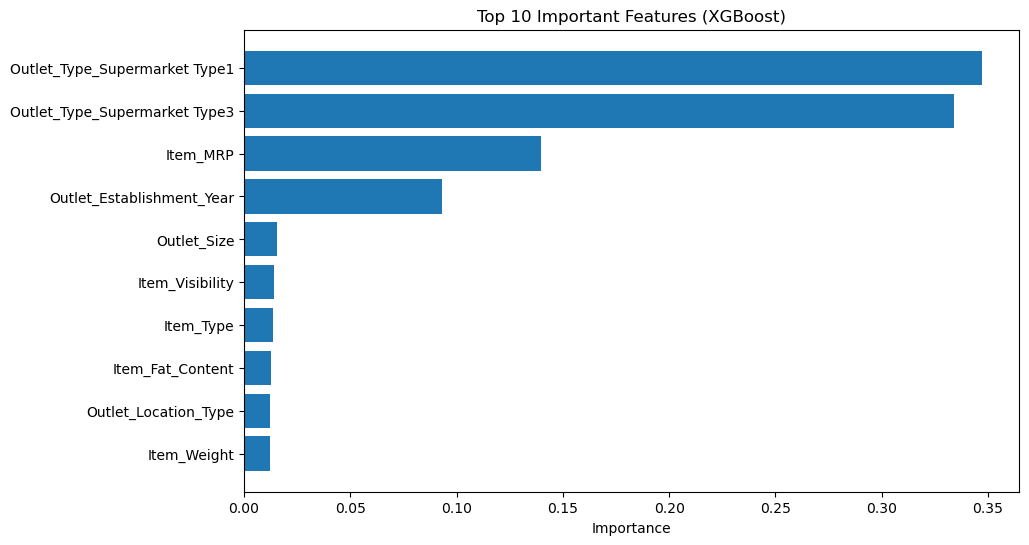

In [145]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Importance")

plt.show()

# Feature Importance

XGBoost provides feature importance scores, which indicate how much each feature contributes to predicting outlet sales.

The top-ranked features have the greatest influence on the model's predictions.

Feature importance helps in:

- Understanding the model.
- Identifying the most influential variables.
- Improving feature engineering in future iterations.
# Feature Importance Analysis (XGBoost)

## Objective

To identify which features contribute the most to predicting outlet sales.

## Observations

- Outlet_Type_Supermarket Type1 is the most influential feature.
- Outlet_Type_Supermarket Type3 is the second most important feature.
- Item_MRP is the most important product-related feature.
- Outlet_Establishment_Year also has a noticeable impact on sales prediction.
- Features such as Item_Weight, Item_Fat_Content, Item_Type, and Item_Visibility have relatively low importance.

## Business Insight

The model indicates that outlet-related characteristics have a stronger influence on sales prediction than most product-specific attributes. This suggests that where a product is sold is often more important than certain characteristics of the product itself.

In [146]:
test_data.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Age', 'Item_Category',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'],
      dtype='object')

In [147]:
X_train.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Age', 'Item_Category',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'],
      dtype='object')

In [148]:
test_prediction = xgb.predict(test_data)

In [149]:
test_data.select_dtypes(include='object').columns

Index([], dtype='object')

In [150]:
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()

# Fit only on train
le_type.fit(train_data['Item_Type'])

# Transform train
train_data['Item_Type'] = le_type.transform(train_data['Item_Type'])

# Transform test
test_data['Item_Type'] = le_type.transform(test_data['Item_Type'])

In [151]:
#vPredict on test_data

In [152]:
list(X.columns) == list(test_data.columns)

True

In [153]:
test_prediction = xgb.predict(test_data)

In [154]:
test_prediction

array([1496.8315 , 1394.0135 ,  826.22046, ..., 2024.8856 , 3524.2615 ,
       1344.4025 ], shape=(5681,), dtype=float32)

In [155]:
test_prediction[:10]

array([1496.8315 , 1394.0135 ,  826.22046, 2574.6672 , 9010.565  ,
       1903.6011 ,  762.14417, 2250.5356 , 1406.306  , 2955.83   ],
      dtype=float32)

# Prediction on Test Dataset

## Objective

After training the XGBoost model, predictions were generated for the unseen test dataset.

## Observation

- The trained model successfully predicted outlet sales for all records in the test dataset.
- These predictions will be used to create the final submission file.

In [157]:
test_original = pd.read_csv(r"C:\Users\soura\Desktop\Projects\Machine Learing Project\Bigmart Sales Prediction\Data\test.csv")

In [158]:
# Create Submission File

submission = pd.DataFrame({
    'Item_Identifier': test_original['Item_Identifier'],
    'Outlet_Identifier': test_original['Outlet_Identifier'],
    'Item_Outlet_Sales': test_prediction
})

submission.to_csv(r"C:\Users\soura\Desktop\Projects\Machine Learing Project\Bigmart Sales Prediction\Output\submission.csv", index=False)

In [159]:
test_original

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3
...,...,...,...,...,...,...,...,...,...,...,...
5676,FDB58,10.500,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1
5677,FDD47,7.600,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2
5678,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1
5679,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1


In [160]:
submission

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1496.831543
1,FDW14,OUT017,1394.013550
2,NCN55,OUT010,826.220459
3,FDQ58,OUT017,2574.667236
4,FDY38,OUT027,9010.565430
...,...,...,...
5676,FDB58,OUT046,2108.599121
5677,FDD47,OUT018,2559.210205
5678,NCO17,OUT045,2024.885620
5679,FDJ26,OUT017,3524.261475
